In [ ]:
# from google.colab import drive

# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/faster_rcnn
# %cp VOC2007.zip /content
# %cp VOC2012.zip /content

In [ ]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

In [69]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [70]:
from src.backbone import backbone_transform
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

transform = backbone_transform

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

combined_train_img_paths = voc2007_img_paths_train + voc2012_img_paths_train

train_dataloader = create_voc_dataloader(img_paths_list=combined_train_img_paths, transform=transform, batch_size=2, shuffle=True)
test_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_test, transform=transform, batch_size=2, shuffle=True)

In [71]:
# from src.backbone import Backbone
# from src.rpn import RPN_Head, RegionProposalNetwork
# from src.roi import RoIPool
# from src.detection_net import DetectionHead, DetectionNet
# import torch
# from pathlib import Path

# # Step-1 RPN network: frozen, exists only to generate proposals.
# backbone_rpn = Backbone().to(device)
# rpn_head = RPN_Head(in_channels=1024, mid_channels=512)

# # rpn_checkpoint_path = Path("/content/drive/MyDrive/faster_rcnn/checkpoints/step1_epoch_10.pt")
# rpn_checkpoint_path = Path("checkpoints/step1_epoch_10.pt")
# rpn_checkpoint = torch.load(rpn_checkpoint_path, map_location=device)

# backbone_rpn.load_state_dict(rpn_checkpoint['backbone_state_dict'])
# rpn_head.load_state_dict(rpn_checkpoint['rpn_head_state_dict'])
# print(f"Loaded RPN Checkpoint: {rpn_checkpoint_path}")

# rpn_net = RegionProposalNetwork(rpn_head).to(device)

# for param in backbone_rpn.parameters():
#     param.requires_grad = False
# for param in rpn_head.parameters():
#     param.requires_grad = False

# # eval() here and never train() again
# backbone_rpn.eval()
# rpn_net.eval()

# # Step-2 detection network: separate, fresh ImageNet weights, trained.
# backbone = Backbone().to(device)
# roi_pool = RoIPool(output_size=(7, 7), pooling_mode="adaptive").to(device)
# detection_head = DetectionHead().to(device)


In [122]:
from torch import nn
import torchvision.ops as ops

class DetectionNet(nn.Module):
    def __init__(self, detection_head, background_label=20, delta_std=(0.1, 0.1, 0.2, 0.2),
                 score_thresh=0.5, nms_iou_thresh=0.5, max_detections_per_image=100,
                 min_box_size=1.0):
        super().__init__()

        self.detection_head = detection_head
        self.background_label = background_label
        self.delta_std = delta_std

        # Inference-time detection settings. score_thresh=0.05 and 100 detections per
        # image are the Fast R-CNN evaluation conventions; both are deliberately low
        # bars, since AP wants the full precision/recall curve rather than one
        # conservative operating point.
        self.score_thresh = score_thresh
        self.nms_iou_thresh = nms_iou_thresh
        self.max_detections_per_image = max_detections_per_image
        self.min_box_size = min_box_size

    def corners_to_center(self, boxes):
        # (x1, y1, x2, y2) -> (x_c, y_c, w, h)
        x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
        w = x2 - x1
        h = y2 - y1
        x_c = x1 + w / 2
        y_c = y1 + h / 2
        return torch.stack([x_c, y_c, w, h], dim=1)

    def select_foreground(self, cls_logits):
        # score per proposal per class, excluding the background class (last column)
        softmax_scores = nn.functional.softmax(cls_logits, dim=-1)      # [N, num_classes + 1]
        fg_scores = softmax_scores[:, :self.background_label]           # [N, num_classes] -- background class is not a foreground class

        proposal_idx, labels = (fg_scores > self.score_thresh).nonzero(as_tuple=True)       # proposal_idx: [K], labels: [K] -- K is the number of proposals that survived score_thresh for at least one class
        scores = fg_scores[proposal_idx, labels]

        return proposal_idx, labels, scores

    def decode_box_deltas(self, proposals_center, box_deltas):
        # proposals_center: [N, 4] (x_c, y_c, w, h)
        # box_deltas: [N, 4] (dx, dy, dw, dh), normalized by self.delta_std (Fast R-CNN convention, matches DetectionLoss.encode_box_targets) -- un-normalize before applying the inverse transform
        std = torch.tensor(self.delta_std, dtype=box_deltas.dtype, device=box_deltas.device)
        dx, dy, dw, dh = (box_deltas * std).unbind(dim=1)

        xc_p, yc_p, w_p, h_p = proposals_center[:, 0], proposals_center[:, 1], proposals_center[:, 2], proposals_center[:, 3]

        xc = dx * w_p + xc_p
        yc = dy * h_p + yc_p
        w = torch.exp(dw) * w_p
        h = torch.exp(dh) * h_p

        xmin = xc - w / 2
        ymin = yc - h / 2
        xmax = xc + w / 2
        ymax = yc + h / 2

        decoded_boxes = torch.stack((xmin, ymin, xmax, ymax), dim=1)
        return decoded_boxes

    def clip_boxes_to_image(self, decoded_boxes, img_height, img_width):
        # decoded_boxes: [N, 4] CORNER absolute px -- same clamp as RegionProposalNetwork.clip_boxes_to_image
        xmin = torch.clamp(decoded_boxes[:, 0], min=0, max=img_width - 1)
        ymin = torch.clamp(decoded_boxes[:, 1], min=0, max=img_height - 1)
        xmax = torch.clamp(decoded_boxes[:, 2], min=0, max=img_width - 1)
        ymax = torch.clamp(decoded_boxes[:, 3], min=0, max=img_height - 1)

        clipped_boxes = torch.stack((xmin, ymin, xmax, ymax), dim=1)
        return clipped_boxes

    def forward(self, rpn_proposals, pooled_proposals, img_sizes_before_pad):
        # rpn_proposals:    list of B x [N_i, 4] CORNER absolute px, from RegionProposalNetwork
        # pooled_proposals: list of B x [N_i, 1024, 7, 7], RoIPool output for the same proposals
        batch_cls_logits, batch_box_deltas = self.detection_head(pooled_proposals)

        batch_size = len(rpn_proposals)

        labels_list = []
        scores_list = []
        boxes_list = []

        for i in range(batch_size):
            img_height, img_width = img_sizes_before_pad[i]

            cls_logits = batch_cls_logits[i]
            box_deltas = batch_box_deltas[i]
            proposals = rpn_proposals[i]

            proposal_idx, labels, scores = self.select_foreground(cls_logits)

            if proposal_idx.numel() == 0:
                # Nothing in this image cleared score_thresh for any class
                labels_list.append(labels)
                scores_list.append(scores)
                boxes_list.append(proposals.new_zeros((0, 4)))
                continue

            # box_deltas is [N, 4 * num_classes] -- reshape to [N, num_classes, 4] 
            num_classes = box_deltas.shape[1] // 4
            selected_proposals = proposals[proposal_idx]
            predicted_deltas = box_deltas.view(-1, num_classes, 4)[proposal_idx, labels]

            proposals_center = self.corners_to_center(selected_proposals)
            decoded_boxes = self.decode_box_deltas(proposals_center, predicted_deltas)
            clipped_boxes = self.clip_boxes_to_image(decoded_boxes, img_height, img_width)

            # Remove boxes that are too small to be valid detections
            widths = clipped_boxes[:, 2] - clipped_boxes[:, 0]
            heights = clipped_boxes[:, 3] - clipped_boxes[:, 1]
            keep = (widths >= self.min_box_size) & (heights >= self.min_box_size)
            clipped_boxes, labels, scores = clipped_boxes[keep], labels[keep], scores[keep]


            if labels.numel() == 0:
                labels_list.append(labels)
                scores_list.append(scores)
                boxes_list.append(clipped_boxes)
                continue

            # Per-CLASS NMS -- boxes of different classes must not suppress each other
            keep_idx = ops.batched_nms(clipped_boxes, scores, labels, self.nms_iou_thresh)
            keep_idx = keep_idx[:self.max_detections_per_image]

            labels_list.append(labels[keep_idx])
            scores_list.append(scores[keep_idx])
            boxes_list.append(clipped_boxes[keep_idx])

        return labels_list, scores_list, boxes_list


In [123]:
from src.backbone import Backbone
from src.rpn import RPN_Head, RegionProposalNetwork
from src.roi import RoIPool
from src.detection_net import DetectionHead
import torch
from pathlib import Path

# Step-1 RPN network: frozen, exists only to generate proposals.
rpn_head = RPN_Head(in_channels=1024, mid_channels=512)

# rpn_checkpoint_path = Path("/content/drive/MyDrive/faster_rcnn/checkpoints/step1_epoch_10.pt")
rpn_checkpoint_path = Path("checkpoints/step3_epoch_10.pt")
rpn_checkpoint = torch.load(rpn_checkpoint_path, map_location=device)

# backbone checkpint_path
backbone_checkpoint_path = Path("checkpoints/step2_epoch_6.pt")
backbone_checkpoint = torch.load(backbone_checkpoint_path, map_location=device)

detection_head_checkpoint_path = Path("checkpoints/step4_epoch_8.pt")
detection_head_checkpoint = torch.load(detection_head_checkpoint_path, map_location=device)

# Step-2 detection network: separate, fresh ImageNet weights, trained.
backbone = Backbone().to(device)
roi_pool = RoIPool(output_size=(7, 7), pooling_mode="adaptive").to(device)
detection_head = DetectionHead().to(device)

rpn_head.load_state_dict(rpn_checkpoint['rpn_head_state_dict'])
print(f"Loaded RPN Checkpoint: {rpn_checkpoint_path}")

backbone.load_state_dict(backbone_checkpoint['backbone_state_dict'])
print(f"Loaded Backbone Checkpoint: {backbone_checkpoint_path}")

detection_head.load_state_dict(detection_head_checkpoint['detection_head_state_dict'])
print(f"Loaded Detection Head Checkpoint: {detection_head_checkpoint_path}")

rpn_network = RegionProposalNetwork(rpn_head=rpn_head).to(device)
detection_network = DetectionNet(detection_head=detection_head, background_label=20, delta_std=(0.1, 0.1, 0.2, 0.2)).to(device)

for param in backbone.parameters():
    param.requires_grad = False
for param in rpn_head.parameters():
    param.requires_grad = False
for param in detection_head.parameters():
    param.requires_grad = False

# eval() here and never train() again
backbone.eval()
rpn_head.eval()
rpn_network.eval()
detection_head.eval()
detection_network.eval()

Loaded RPN Checkpoint: checkpoints/step3_epoch_10.pt
Loaded Backbone Checkpoint: checkpoints/step2_epoch_6.pt
Loaded Detection Head Checkpoint: checkpoints/step4_epoch_8.pt


DetectionNet(
  (detection_head): DetectionHead(
    (conv5_x): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): Bottleneck(
        (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(

In [134]:
batch_imgs, batch_boxes, batch_labels, batch_img_sizes_before_pad = next(iter(test_dataloader))

with torch.inference_mode():
    batch_imgs = batch_imgs.to(device)
    batch_gt_boxes = [boxes.to(device) for boxes in batch_boxes]         # Not needed as the functions take care, but for safety
    batch_gt_labels = [labels.to(device) for labels in batch_labels]
    
    backbone.eval()
    rpn_head.eval()
    rpn_network.eval()
    roi_pool.eval()
    detection_head.eval()
    detection_network.eval()

    batch_feature_maps = backbone(batch_imgs)
    batch_scores, batch_proposals = rpn_network(batch_feature_maps, batch_img_height=batch_imgs.shape[2],  batch_img_width=batch_imgs.shape[3], img_sizes_before_pad=batch_img_sizes_before_pad, pre_nms_top_n=6000, post_nms_top_n=2000)
    

    print(f"batch_feature_maps.shape: {batch_feature_maps.shape}")
    pooled_batch = roi_pool(batch_feature_maps, batch_proposals, batch_imgs.shape[2], batch_imgs.shape[3])

    batch_pred_labels, batch_pred_scores, batch_pred_boxes = detection_network(batch_proposals, pooled_batch, batch_img_sizes_before_pad)


batch_feature_maps.shape: torch.Size([2, 1024, 50, 50])


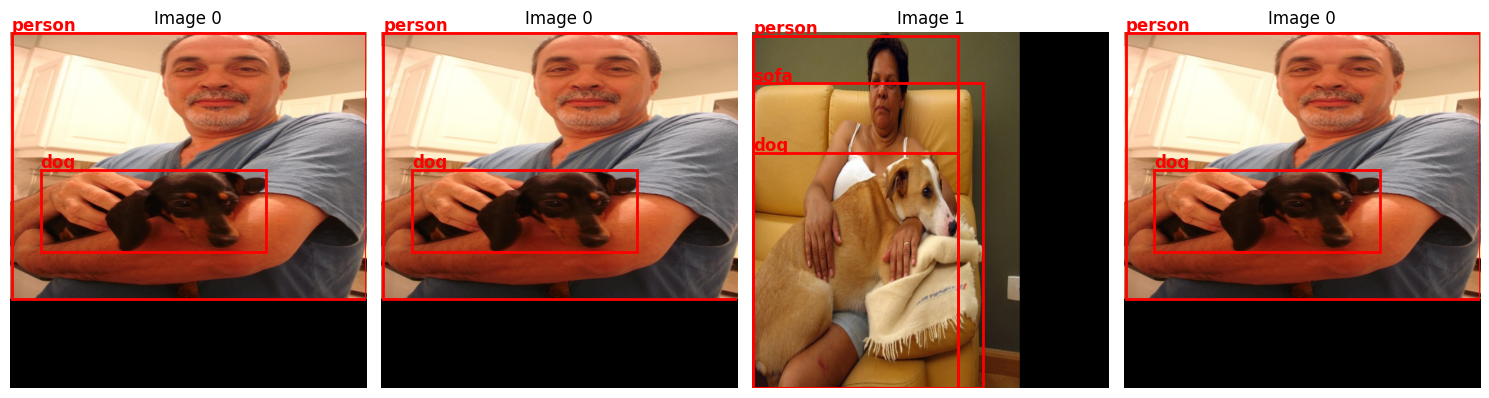

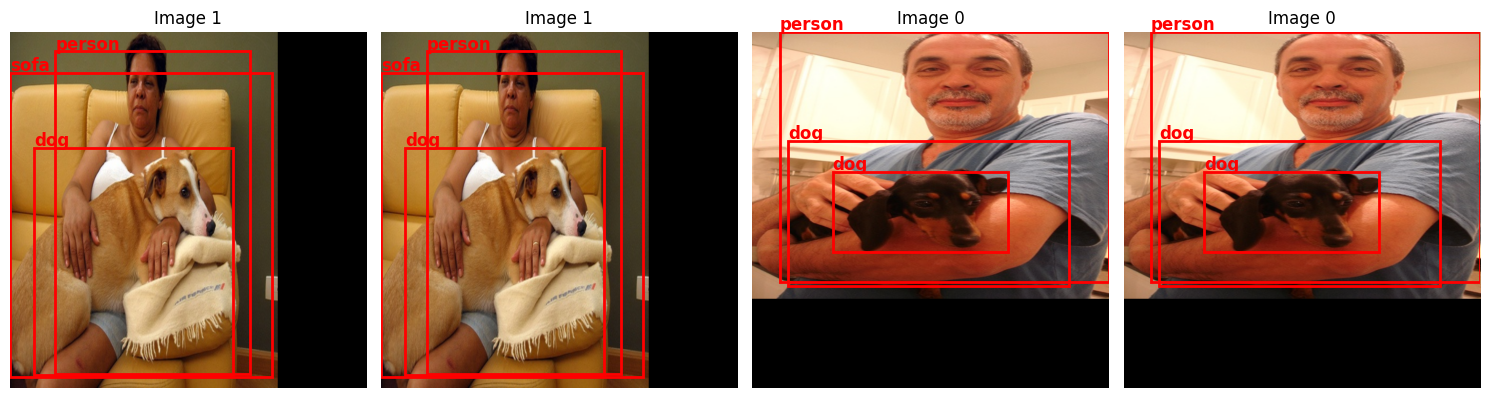

In [135]:
from src.utils import display_random_batch_images

display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
display_random_batch_images(batch_imgs, batch_pred_boxes, batch_pred_labels, num_images=4)

In [133]:
# from torchvision.ops import batched_nms

# for i in range(len(batch_imgs)):
#     boxes = batch_pred_boxes[i]
#     scores = batch_pred_scores[i]
#     labels = batch_pred_labels[i]

#     keep_indices = batched_nms(boxes, scores, labels, iou_threshold=0.5)

#     batch_pred_boxes[i] = boxes[keep_indices]
#     batch_pred_scores[i] = scores[keep_indices]
#     batch_pred_labels[i] = labels[keep_indices]

In [63]:
# from src.utils import display_random_batch_images
# import matplotlib.pyplot as plt
# import random

# num_images = 4
# fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
# for i in range(num_images):
#     idx = random.randint(0, len(batch_imgs) - 1)
#     img = batch_imgs[idx].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format and move to CPU
#     axes[i].imshow(img)
#     axes[i].set_title(f"Image {idx}")
#     axes[i].axis('off')
    
# display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
# display_random_batch_images(batch_imgs, batch_pred_boxes, batch_pred_labels, num_images=4)

In [64]:
def compute_iou_matrix(boxes_a, boxes_b):
    # boxes_a: [num_a, 4], boxes_b: [num_b, 4] -- BOTH in CORNER format (x1, y1, x2, y2).
    # Returns: IoU matrix of shape [num_a, num_b]
    a_x1, a_y1, a_x2, a_y2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
    b_x1, b_y1, b_x2, b_y2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]

    inter_x1 = torch.max(a_x1.unsqueeze(1), b_x1.unsqueeze(0))
    inter_y1 = torch.max(a_y1.unsqueeze(1), b_y1.unsqueeze(0))
    inter_x2 = torch.min(a_x2.unsqueeze(1), b_x2.unsqueeze(0))
    inter_y2 = torch.min(a_y2.unsqueeze(1), b_y2.unsqueeze(0))

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)

    area_a = (a_x2 - a_x1) * (a_y2 - a_y1)
    area_b = (b_x2 - b_x1) * (b_y2 - b_y1)
    union_area = area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter_area

    return inter_area / union_area

In [65]:
from tqdm import tqdm
import torchvision.ops as ops

def run_inference_full_testset(test_dataloader, backbone, rpn_network, roi_pool, detection_network, device, nms_iou_threshold=0.5):
    # Returns:
    #   all_preds: dict class_idx -> list of (score, img_id, box[4]) CORNER format, across the whole test set
    #   all_gts:   dict (img_id, class_idx) -> GT boxes tensor [num_gt, 4] CORNER format
    all_preds = {}
    all_gts = {}

    img_id = 0

    backbone.eval()
    rpn_network.eval()
    roi_pool.eval()
    detection_network.eval()

    with torch.inference_mode():
        for batch_imgs, batch_boxes, batch_labels, batch_img_sizes_before_pad in tqdm(test_dataloader):
            batch_imgs = batch_imgs.to(device)
            batch_gt_boxes = [boxes.to(device) for boxes in batch_boxes]
            batch_gt_labels = [labels.to(device) for labels in batch_labels]

            # Calculate feature maps, proposals, pooled features, and predictions
            batch_feature_maps = backbone(batch_imgs)
            _, batch_proposals = rpn_network(
                batch_feature_maps,
                batch_img_height=batch_imgs.shape[2],
                batch_img_width=batch_imgs.shape[3],
                img_sizes_before_pad=batch_img_sizes_before_pad,
                pre_nms_top_n=6000,
                post_nms_top_n=2000,
            )
            pooled_batch = roi_pool(batch_feature_maps, batch_proposals, batch_imgs.shape[2], batch_imgs.shape[3])
            batch_pred_labels, batch_pred_scores, batch_pred_boxes = detection_network(batch_proposals, pooled_batch, batch_img_sizes_before_pad)

            # Loop through each image in the batch and apply NMS, then store predictions and ground truths
            for i in range(len(batch_imgs)):
                pred_boxes = batch_pred_boxes[i]
                pred_scores = batch_pred_scores[i]
                pred_labels = batch_pred_labels[i]

                # if pred_boxes.shape[0] > 0:
                #     keep_idx = ops.batched_nms(pred_boxes, pred_scores, pred_labels, iou_threshold=nms_iou_threshold)
                #     pred_boxes = pred_boxes[keep_idx]
                #     pred_scores = pred_scores[keep_idx]
                #     pred_labels = pred_labels[keep_idx]

                # For each predicted box, store the score, image ID, and box coordinates in all_preds, so that w.r.t to the cls_idx, we have check the box, its score, image_id
                for cls_idx, score, box in zip(pred_labels.tolist(), pred_scores.tolist(), pred_boxes):
                    all_preds.setdefault(cls_idx, []).append((score, img_id, box.detach().cpu()))

                # Store the gt_boxes with corresponding image_id and cls_idx
                gt_boxes = batch_gt_boxes[i]
                gt_labels = batch_gt_labels[i]
                for cls_idx in gt_labels.unique().tolist():
                    all_gts[(img_id, cls_idx)] = gt_boxes[gt_labels == cls_idx].detach().cpu()

                # Generating new Image Id per image
                img_id += 1

    return all_preds, all_gts

In [66]:
def compute_ap_for_class(class_preds, class_gts, iou_threshold=0.5):
    # class_preds: list of (score, img_id, box[4]) CORNER format, for a single class across the whole test set
    # class_gts:   dict img_id -> GT boxes tensor [num_gt, 4] CORNER format, for this same class

    # calculating the total number of ground truth boxes for this class across all images
    total_gt = sum(gt_boxes.shape[0] for gt_boxes in class_gts.values())

    # if total_gt or preds for this class is zero, return 0.0 AP and empty precision/recall tensors
    if total_gt == 0 or len(class_preds) == 0:
        return 0.0, torch.tensor([]), torch.tensor([])

    # sorting pred_boxes for the class based on pred_scores
    sorted_preds = sorted(class_preds, key=lambda x: x[0], reverse=True)

    # Per-image mutable copy of GT boxes so matched boxes can be removed as we go.
    remaining_gts = {img_id: gt_boxes.clone() for img_id, gt_boxes in class_gts.items()}

    # tensor to keep track for each pred_box whether it's a true positive or false positive
    tp = torch.zeros(len(sorted_preds))
    fp = torch.zeros(len(sorted_preds))

    # Loop throught each predicted box in sorted_preds(pred_boxes sorted in descending order of scores) and determine if it's a true positive or false positive
    for i, (score, img_id, box) in enumerate(sorted_preds):
        gt_boxes = remaining_gts.get(img_id)

        if gt_boxes is None or gt_boxes.shape[0] == 0:
            fp[i] = 1
            continue

        iou_matrix = compute_iou_matrix(box.unsqueeze(0), gt_boxes)  # [1, num_gt]
        max_iou, max_idx = iou_matrix[0].max(dim=0)

        if max_iou.item() >= iou_threshold:
            tp[i] = 1
            keep_mask = torch.ones(gt_boxes.shape[0], dtype=torch.bool)
            keep_mask[max_idx] = False
            remaining_gts[img_id] = gt_boxes[keep_mask]
        else:
            fp[i] = 1

    cum_tp = torch.cumsum(tp, dim=0)
    cum_fp = torch.cumsum(fp, dim=0)

    precisions = cum_tp / (cum_tp + cum_fp)
    recalls = cum_tp / total_gt     # Recall can be calculated using total_gt without needing False Negatives

    # Calculating Average Precision (AP) using 11-point interpolation method
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recalls >= t
        p = precisions[mask].max().item() if mask.any() else 0.0
        ap += p / 11

    return ap, precisions, recalls

In [67]:
def compute_map(all_preds, all_gts, iou_threshold=0.5):
    # all_preds: dict class_idx -> list of (score, img_id, box[4]) CORNER format, from run_inference_full_testset
    # all_gts:   dict (img_id, class_idx) -> GT boxes tensor [num_gt, 4] CORNER format, from run_inference_full_testset
    per_class_ap = {}
    per_class_recall = {}

    header = f"{'class':>12}  {'AP':>6}  {'rec[-1]':>7}  {'AP_ceil':>7}  {'n_det':>7}  {'n_gt':>5}"
    print(header)
    print("-" * len(header))

    for cls_idx, cls_name in enumerate(VOC_CLASSES):
        # Get list of predictions for this class (cls_idx) from all_preds, and the corresponding ground truth boxes from all_gts
        class_preds = all_preds.get(cls_idx, [])

        # Get dict of gt_boxes(img_id -> gt_boxes) for this class (cls_idx) from all_gts
        class_gts = {
            img_id: gt_boxes
            for (img_id, gt_idx), gt_boxes in all_gts.items()
            if gt_idx == cls_idx
        }

        # Number of ground truth boxes for this class across all images
        total_gt = sum(gt_boxes.shape[0] for gt_boxes in class_gts.values())

        # If total_gt is zero, set AP to None and print a message indicating no GT boxes for this class
        if total_gt == 0:
            per_class_ap[cls_idx] = None
            per_class_recall[cls_idx] = None
            print(f"{cls_name:>12}: N/A (no GT boxes in test set)")
            continue

        # computing AP for this class using the compute_ap_for_class function
        ap, precisions, recalls = compute_ap_for_class(class_preds, class_gts, iou_threshold=iou_threshold)

        # recalls is cumulative and monotonically non-decreasing, so recalls[-1] is the
        # highest recall reachable with every detection the model emitted. No score
        # threshold can exceed it -- it is a ceiling imposed by what was detected at all.
        max_recall = recalls[-1].item() if recalls.numel() > 0 else 0.0

        # 11-point interpolation scores p_interp(t) = 0 for every t above recalls[-1], so
        # the recall ceiling alone caps AP at (reachable points) / 11 -- even if precision
        # were perfect everywhere below it. Comparing AP against AP_ceil separates
        # "missed the object entirely" from "detected it but ranked it badly".
        reachable = int((torch.linspace(0, 1, 11) <= max_recall).sum().item())
        ap_ceiling = reachable / 11

        per_class_ap[cls_idx] = ap
        per_class_recall[cls_idx] = max_recall
        print(f"{cls_name:>12}  {ap:6.4f}  {max_recall:7.4f}  {ap_ceiling:7.4f}  {len(class_preds):7d}  {total_gt:5d}")

    valid_aps = [ap for ap in per_class_ap.values() if ap is not None]
    valid_recalls = [r for r in per_class_recall.values() if r is not None]
    mean_ap = sum(valid_aps) / len(valid_aps) if valid_aps else 0.0
    mean_recall = sum(valid_recalls) / len(valid_recalls) if valid_recalls else 0.0

    print(f"\nmAP @ IoU {iou_threshold}: {mean_ap:.4f}")
    print(f"mean recall[-1] @ IoU {iou_threshold}: {mean_recall:.4f}")
    print(f"total detections: {sum(len(p) for p in all_preds.values())}   total GT: {sum(g.shape[0] for g in all_gts.values())}")
    return mean_ap, per_class_ap, per_class_recall

In [68]:
from src.dataset import VOC_CLASSES


all_preds, all_gts = run_inference_full_testset(test_dataloader, backbone, rpn_network, roi_pool, detection_network, device)
mean_ap, per_class_ap, per_class_recall = compute_map(all_preds, all_gts, iou_threshold=0.5)

100%|██████████| 2476/2476 [11:53<00:00,  3.47it/s]


       class      AP  rec[-1]  AP_ceil    n_det   n_gt
------------------------------------------------------
   aeroplane  0.6753   0.8006   0.8182     2002    311
     bicycle  0.6762   0.8303   0.8182     1669    389
        bird  0.5652   0.7205   0.7273     2721    576
        boat  0.4054   0.6539   0.6364     4209    393
      bottle  0.2152   0.4140   0.4545     3574    657
         bus  0.6891   0.8307   0.8182     1442    254
         car  0.6062   0.7729   0.7273     9675   1541
         cat  0.8460   0.9378   0.9091     1310    370
       chair  0.3179   0.6492   0.6364    14230   1374
         cow  0.5590   0.7629   0.7273     1635    329
 diningtable  0.5629   0.7826   0.7273     1803    299
         dog  0.8014   0.9170   0.9091     2082    530
       horse  0.7313   0.8810   0.8182     2071    395
   motorbike  0.7014   0.8591   0.8182     1753    369
      person  0.6007   0.7915   0.7273    27469   5227
 pottedplant  0.3001   0.6014   0.6364     6769    592
       she

In [41]:
# Re-scores the detections already sitting in memory -- does NOT re-run inference.
# Run the compute_ap_for_class / compute_map definition cells above first, then this.
mean_ap, per_class_ap, per_class_recall = compute_map(all_preds, all_gts, iou_threshold=0.5)

       class      AP  rec[-1]  AP_ceil    n_det   n_gt
------------------------------------------------------
   aeroplane  0.6186   0.6495   0.6364      310    311
     bicycle  0.5940   0.6838   0.6364      403    389
        bird  0.4919   0.5903   0.5455      631    576
        boat  0.3676   0.4300   0.4545      399    393
      bottle  0.1896   0.2161   0.2727      397    657
         bus  0.6657   0.7087   0.7273      288    254
         car  0.5824   0.6106   0.6364     1603   1541
         cat  0.8002   0.8459   0.8182      466    370
       chair  0.2568   0.3843   0.3636     1597   1374
         cow  0.5026   0.5593   0.5455      304    329
 diningtable  0.4872   0.5686   0.5455      298    299
         dog  0.7715   0.8377   0.8182      690    530
       horse  0.6856   0.7949   0.7273      558    395
   motorbike  0.6029   0.6992   0.6364      409    369
      person  0.5646   0.6254   0.6364     5792   5227
 pottedplant  0.2462   0.3429   0.3636      680    592
       she